In [227]:
import pandas as pd 
import wandb
api = wandb.Api()


runs = api.runs("pbragali/DeepLearning")

summary_list, config_list, name_list = [], [], []
runs_df = list()
for run in runs:
    run_df = dict()
    if run.state != "finished":
        continue
    # .summary contains the output keys/values for metrics like accuracy.
    #  We call ._json_dict to omit large files 
    summary_list.append(run.summary._json_dict)

    # .config contains the hyperparameters.
    #  We remove special values that start with _.
    config_list.append(
        {k: v for k,v in run.config.items()
          if not k.startswith('_')})

    # .name is the human-readable name of the run.
    name_list.append(run.name)

    run_df["name"] = run.name
    for k,v in run.config.items():
        if not k.startswith('_'):
            run_df[k] = v

    for k,v in run.summary._json_dict.items():
        if k == 'learning_rate':
            continue
        run_df[k] = v
    runs_df.append(run_df)

# runs_df = pd.DataFrame({
#     "summary": summary_list,
#     "config": config_list,
#     "name": name_list
#     })

runs_df = pd.DataFrame.from_records(runs_df)

In [228]:
hyperparams = ['learning_rate', 'model_name', 'alpha', 'latent_dim_size', 'window_size']
metrics = ['accuracy', 'classification_loss',
       'f1_score', 'precision', 'reconstruction_loss', #  'recall',
       'roc_auc', 'sp_index', 'total_loss',
       'val_classification_loss', 'val_reconstruction_loss', 'val_total_loss']
df = runs_df[hyperparams + metrics + ['fold']]
df = df.loc[df['sp_index'] > 0.5]
df = df.loc[df['alpha'] != 0.3]
df.loc[df.model_name == 'MultitaskAutoencoder', 'window_size'] = 1.0


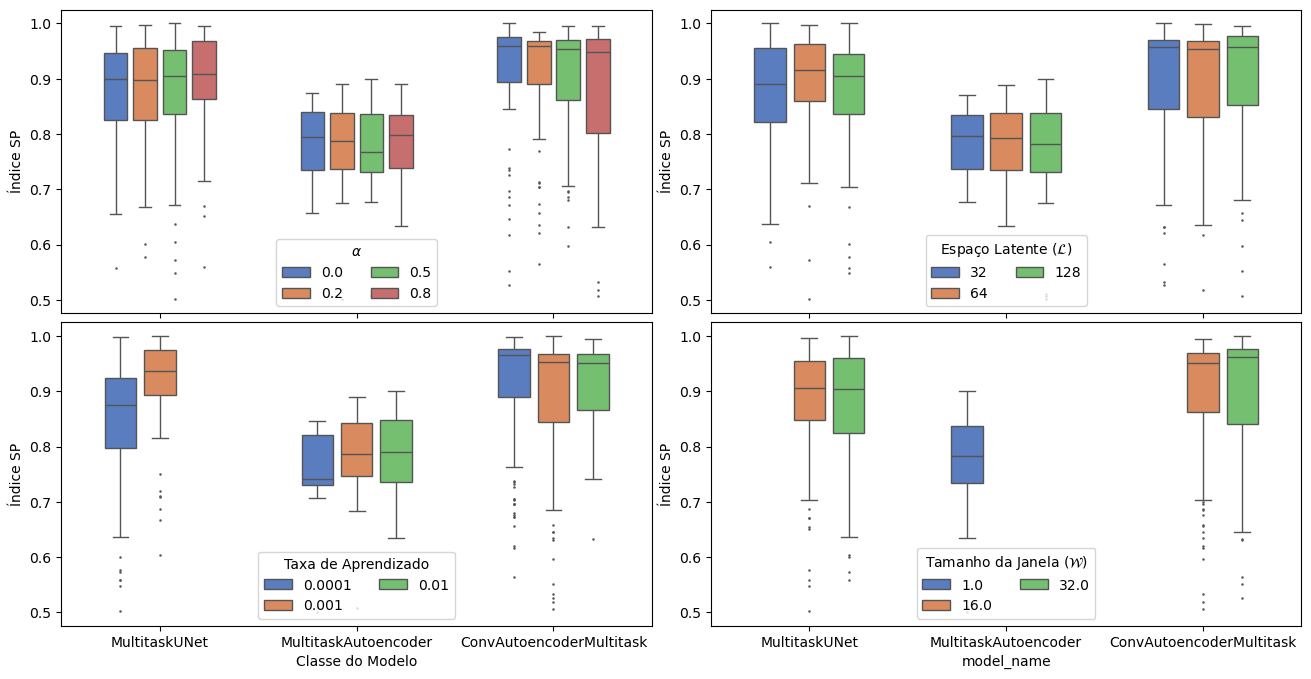

In [229]:
import seaborn as sns
import matplotlib.pyplot as plt
nrows = 2 
ncols = 2
fig, axes = plt.subplots(nrows, ncols, figsize=(8*ncols, 4*nrows), sharex=True)
fig.subplots_adjust(hspace=0.03, wspace=0.1)
sns.boxplot(x='model_name', y='sp_index', hue='alpha', data=df, palette='muted',
            ax=axes[0, 0], width=0.6, dodge=True, gap=0.2, fliersize=0.8)

sns.boxplot(x='model_name', y='sp_index', hue='learning_rate', data=df, palette='muted',
            ax=axes[1, 0], width=0.6, dodge=True, gap=0.2, fliersize=0.8)

sns.boxplot(x='model_name', y='sp_index', hue='latent_dim_size', data=df, palette='muted',
            ax=axes[0, 1], width=0.6, dodge=True, gap=0.2, fliersize=0.8)

sns.boxplot(x='model_name', y='sp_index', hue='window_size', data=df, palette='muted',
            ax=axes[1, 1], width=0.6, dodge=True, gap=0.2, fliersize=0.8)

axes[1, 0].xaxis.set_tick_params(rotation=0)
axes[1, 0].set_xlabel('Classe do Modelo')
axes[1, 0].set_ylabel('Índice SP')
axes[1, 0].legend(title='Taxa de Aprendizado', loc='lower center', ncol=2)

axes[0, 0].set_ylabel('Índice SP')
axes[0, 0].legend(title='$\\alpha$', loc='lower center', ncol=2)

axes[0, 1].set_ylabel('Índice SP')
axes[0, 1].legend(title='Espaço Latente ($\\mathcal{L}$)', loc='lower center', ncol=2)


axes[1, 1].set_ylabel('Índice SP')
axes[1, 1].legend(title='Tamanho da Janela ($\\mathcal{W}$)', loc='lower center', ncol=2)

In [230]:
df_mean = df.groupby(hyperparams).mean().reset_index().drop(columns=['fold'])
df_std = df.groupby(hyperparams).std().reset_index().drop(columns=['fold'])

df_mt = df_mean.loc[df_mean.model_name == 'MultitaskAutoencoder'].sort_values(by='sp_index', ascending=False, inplace=False)
df_mt_std = df_std.loc[df_std.model_name == 'MultitaskAutoencoder'].sort_values(by='sp_index', ascending=False, inplace=False)

df_cvmt = df_mean.loc[df_mean.model_name == 'ConvAutoencoderMultitask'].sort_values(by='sp_index', ascending=False, inplace=False)
df_cvmt_std = df_std.loc[df_std.model_name == 'ConvAutoencoderMultitask'].sort_values(by='sp_index', ascending=False, inplace=False)

df_unet = df_mean.loc[df_mean.model_name == 'MultitaskUNet'].sort_values(by='sp_index', ascending=False, inplace=False)
df_unet_std = df_std.loc[df_std.model_name == 'MultitaskUNet'].sort_values(by='sp_index', ascending=False, inplace=False)

In [231]:
for a in [0.8, 0.5, 0.2, 0.0]:
    display(df_unet.loc[df_unet.alpha == a].head(1))
    display(df_unet_std.loc[df_unet.loc[df_unet.alpha == a].head(1).index].head(1))

    scores_mean = df_unet.loc[df_unet.alpha == a].head(1)[['accuracy', 'precision', 'f1_score', 'sp_index']]
    scores_std = df_unet_std.loc[df_unet.loc[df_unet.alpha == a].head(1).index].head(1)[['accuracy', 'precision', 'f1_score', 'sp_index']]
    c = 0
    for m, s in zip(scores_mean.values[0], scores_std.values[0]):
        if c>2:
            print(f'$ {100*m:.2f} \\pm {100*s:.2f} $', end=' \\\\ ')
        else:
            print(f'$ {100*m:.2f} \\pm {100*s:.2f} $', end=' & ')
        c+=1
    print()

,learning_rate,model_name,alpha,latent_dim_size,window_size,accuracy,classification_loss,f1_score,precision,reconstruction_loss,roc_auc,sp_index,total_loss,val_classification_loss,val_reconstruction_loss,val_total_loss
117,0.001,MultitaskUNet,0.8,64,32.0,0.969088,0.000025,0.971326,0.972267,0.0035,0.980497,0.968887,0.002805,0.680365,0.003454,0.163702


,learning_rate,model_name,alpha,latent_dim_size,window_size,accuracy,classification_loss,f1_score,precision,reconstruction_loss,roc_auc,sp_index,total_loss,val_classification_loss,val_reconstruction_loss,val_total_loss
117,0.001,MultitaskUNet,0.8,64,32.0,0.025542,0.000034,0.025377,0.024623,0.000764,0.018551,0.025724,0.000616,0.844891,0.000886,0.175076


$ 96.91 \pm 2.55 $ & $ 97.23 \pm 2.46 $ & $ 97.13 \pm 2.54 $ & $ 96.89 \pm 2.57 $ \\ 


,learning_rate,model_name,alpha,latent_dim_size,window_size,accuracy,classification_loss,f1_score,precision,reconstruction_loss,roc_auc,sp_index,total_loss,val_classification_loss,val_reconstruction_loss,val_total_loss
113,0.001,MultitaskUNet,0.5,128,32.0,0.947917,0.000018,0.958384,0.963595,0.010052,0.972439,0.94585,0.005035,0.391116,0.00991,0.24511


,learning_rate,model_name,alpha,latent_dim_size,window_size,accuracy,classification_loss,f1_score,precision,reconstruction_loss,roc_auc,sp_index,total_loss,val_classification_loss,val_reconstruction_loss,val_total_loss
113,0.001,MultitaskUNet,0.5,128,32.0,0.047173,0.000019,0.043929,0.038473,0.003065,0.028967,0.048779,0.001542,0.44232,0.003072,0.221273


...

,learning_rate,model_name,alpha,latent_dim_size,window_size,accuracy,classification_loss,f1_score,precision,reconstruction_loss,roc_auc,sp_index,total_loss,val_classification_loss,val_reconstruction_loss,val_total_loss
104,0.001,MultitaskUNet,0.2,64,16.0,0.026198,0.00001,0.022083,0.018618,0.003606,0.014265,0.027479,0.000729,0.630167,0.003639,0.501827


$ 95.66 \pm 2.62 $ & $ 96.65 \pm 1.86 $ & $ 96.38 \pm 2.21 $ & $ 95.53 \pm 2.75 $ \\ 


,learning_rate,model_name,alpha,latent_dim_size,window_size,accuracy,classification_loss,f1_score,precision,reconstruction_loss,roc_auc,sp_index,total_loss,val_classification_loss,val_reconstruction_loss,val_total_loss
97,0.001,MultitaskUNet,0.0,32,32.0,0.930582,0.000046,0.944519,0.947021,0.059096,0.962402,0.929384,0.000046,0.341176,0.058975,0.341176


,learning_rate,model_name,alpha,latent_dim_size,window_size,accuracy,classification_loss,f1_score,precision,reconstruction_loss,roc_auc,sp_index,total_loss,val_classification_loss,val_reconstruction_loss,val_total_loss
97,0.001,MultitaskUNet,0.0,32,32.0,0.06746,0.000036,0.052029,0.048708,0.020621,0.03582,0.068977,0.000036,0.030872,0.01927,0.030872


$ 93.06 \pm 6.75 $ & $ 94.70 \pm 4.87 $ & $ 94.45 \pm 5.20 $ & $ 92.94 \pm 6.90 $ \\ 


In [232]:
import seaborn as sns

sns.boxplot(x='model_name', y='sp_index', hue='', data=df)

ValueError: Could not interpret value `` for `hue`. An entry with this name does not appear in `data`.